# Secondary ONS Data Join - IMD Deprivation Domains

This notebook details join steps with IMD Deprivation Domains, i.e. the broad deprivation factors that are combined to evaluate overall deprivation in an area (_as already joined as IMD 2025 deciles_).  

The usefulness of this additional layer of detail has not yet been determined: it may be the case that the domain-level relationships align closely with the already examined FSA Rating-IMD Decile (combined factor) relationship, and no new enrichment is gained from this secondary join.  

With this in mind, I will apply the same Kruskal-Wallis test to each domain factor, and will proceed (or not) on the basis of the findings that result.  

### Load, inspect, prepare & join data:

First, I will load and inspect the file, saved to `../data/raw/imd_2025_domains.csv`:

__[English indices of deprivation 2025](https://www.gov.uk/government/statistics/english-indices-of-deprivation-2025)__ - as with the combined deciles data already joined: "Statistics on relative deprivation in small areas in England" - but at domain-level (e.g. Employment, Education & Skills). **File size is approx. 4MB**

In [10]:
# load and check domain-level IMD data:
import pandas as pd

imd_domains = pd.read_csv("../data/raw/imd_2025_domains.csv")

print(imd_domains.shape)
print(imd_domains.columns.tolist())
imd_domains.head()

(33755, 20)
['LSOA code (2021)', 'LSOA name (2021)', 'Local Authority District code (2024)', 'Local Authority District name (2024)', 'Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)', 'Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)', 'Income Rank (where 1 is most deprived)', 'Income Decile (where 1 is most deprived 10% of LSOAs)', 'Employment Rank (where 1 is most deprived)', 'Employment Decile (where 1 is most deprived 10% of LSOAs)', 'Education, Skills and Training Rank (where 1 is most deprived)', 'Education, Skills and Training Decile (where 1 is most deprived 10% of LSOAs)', 'Health Deprivation and Disability Rank (where 1 is most deprived)', 'Health Deprivation and Disability Decile (where 1 is most deprived 10% of LSOAs)', 'Crime Rank (where 1 is most deprived)', 'Crime Decile (where 1 is most deprived 10% of LSOAs)', 'Barriers to Housing and Services Rank (where 1 is most deprived)', 'Barriers to Housing and Services Decil

,LSOA code (2021),LSOA name (2021),Local Authority District code (2024),Local Authority District name (2024),Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs),Income Rank (where 1 is most deprived),Income Decile (where 1 is most deprived 10% of LSOAs),Employment Rank (where 1 is most deprived),Employment Decile (where 1 is most deprived 10% of LSOAs),"Education, Skills and Training Rank (where 1 is most deprived)","Education, Skills and Training Decile (where 1 is most deprived 10% of LSOAs)",Health Deprivation and Disability Rank (where 1 is most deprived),Health Deprivation and Disability Decile (where 1 is most deprived 10% of LSOAs),Crime Rank (where 1 is most deprived),Crime Decile (where 1 is most deprived 10% of LSOAs),Barriers to Housing and Services Rank (where 1 is most deprived),Barriers to Housing and Services Decile (where 1 is most deprived 10% of LSOAs),Living Environment Rank (where 1 is most deprived),Living Environment Decile (where 1 is most deprived 10% of LSOAs)
0,E01000001,City of London 001A,E09000001,City of London,26525,8,33730,10,33708,10,33755,10,33108,10,33698,10,29220,9,244,1
1,E01000002,City of London 001B,E09000001,City of London,31203,10,33669,10,33734,10,33672,10,32574,10,33712,10,32640,10,3702,2
2,E01000003,City of London 001C,E09000001,City of London,25913,8,25167,8,26985,8,30273,9,20719,7,27325,9,30400,10,4540,2
3,E01000005,City of London 001E,E09000001,City of London,14807,5,14836,5,17911,6,15886,5,10458,4,25630,8,11294,4,5403,2
4,E01000006,Barking and Dagenham 016A,E09000002,Barking and Dagenham,10917,4,7519,3,15286,5,11134,4,21901,7,17875,6,2745,1,9479,3


-> 33755 rows matches the expected England-wide LSOA count, column count matches expected (4 identifiers, 2x overall IMD, 7x pairs for each domain).  

As with the combined deciles, I'll rename columns for easier handling / better readability before proceeding with the main data join:

In [11]:
# rename IMD domain dataset columns:

imd_domains.columns = [
    "lsoa21cd", "lsoa21nm",
    "lad_code", "lad_name", # lad = Local Authority District
    "imd_rank", "imd_decile",
    "income_rank", "income_decile",
    "employment_rank", "employment_decile",
    "education_rank", "education_decile",
    "health_rank", "health_decile",
    "crime_rank", "crime_decile",
    "barriers_rank", "barriers_decile",
    "living_env_rank", "living_env_decile",
]

print(imd_domains.columns.tolist())

['lsoa21cd', 'lsoa21nm', 'lad_code', 'lad_name', 'imd_rank', 'imd_decile', 'income_rank', 'income_decile', 'employment_rank', 'employment_decile', 'education_rank', 'education_decile', 'health_rank', 'health_decile', 'crime_rank', 'crime_decile', 'barriers_rank', 'barriers_decile', 'living_env_rank', 'living_env_decile']


In [12]:
# load main dataset

df = pd.read_csv(
    "../data/processed/fsa_london_establishments_with_imd.csv",
    dtype={"PostCode": str, "postcode_tier": str, "lsoa21cd": str, "RightToReply": str}
        # RightToReply throws DtypeWarning otherwise (mostly empty string w/ occasional free-text values)
)

print(df.shape) # should be (81217, 33)

(81217, 33)


In [13]:
# join domain deciles to main dataset:

# domain deciles columns to retain
domain_deciles = [
    "income_decile", "employment_decile", "education_decile",
    "health_decile", "crime_decile", "barriers_decile", "living_env_decile"
]

df = df.merge(
    imd_domains[["lsoa21cd"] + domain_deciles],
    on="lsoa21cd",
    how="left",
)

# inspect post join, show matched rows count
print(df.shape) # should be (81217, 40)
print(df[domain_deciles].notna().sum()) # should show 70462 for each

(81217, 40)
income_decile        70462
employment_decile    70462
education_decile     70462
health_decile        70462
crime_decile         70462
barriers_decile      70462
living_env_decile    70462
dtype: int64


-> resulting DataFrame of 81,217 rows and 40 columns is as expected, with 70,462 domain decile-matched rows also expected count.  

I will then rebuild the `gradable` rating DataFrame and rating `tier` column as in the primary join notebook (`./03_ons_join.ipynb`):

In [14]:
gradable = df[df["RatingValue"].isin(["0","1","2","3","4","5"]) & df["imd_decile"].notna()].copy()

gradable["rating_int"] = gradable["RatingValue"].astype(int)
gradable["tier"] = pd.cut(
    gradable["rating_int"],
    bins=[-1, 2, 4, 5],
    labels=["critical", "fail", "pass"],
)

print(len(gradable)) # should be 63,409 rows

63409


### Kruskal-Wallis tests:

With the data loaded, inspected, joined and prepared, I can then move on to testing the statistical significance and effect size of each domain-rating tier relationship.  

I will use the same Kruskal-Wallis test as before, but will test all eight factors (7 domain deciles and overall decile) in a loop rather than rewriting the same code:

In [15]:
from scipy import stats

# dict to map readable label to column names:
decile_columns = {
    "Overall IMD": "imd_decile",
    "Income": "income_decile",
    "Employment": "employment_decile",
    "Education": "education_decile",
    "Health": "health_decile",
    "Crime": "crime_decile",
    "Barriers to Housing": "barriers_decile",
    "Living Environment": "living_env_decile",
}

results = []

# loop and test
for label, col in decile_columns.items():
    # passing rating tier groups as *args as before
    groups = [gradable.loc[gradable["tier"] == t, col] for t in ["critical", "fail", "pass"]]
    h_stat, p_value = stats.kruskal(*groups)

    n = len(gradable)
    k = 3
    epsilon_squared = (h_stat - k + 1) / (n - k)

    results.append({
        "domain": label,
        "h_stat": h_stat,
        "p_value": p_value,
        "epsilon_squared": epsilon_squared,
    })

results_df = pd.DataFrame(results).sort_values("epsilon_squared", ascending=False)
print(results_df)

                domain       h_stat        p_value  epsilon_squared
1               Income  1503.132120   0.000000e+00         0.023675
0          Overall IMD  1477.176407   0.000000e+00         0.023266
3            Education  1442.396102   0.000000e+00         0.022717
6  Barriers to Housing  1289.419305  1.014274e-280         0.020304
2           Employment   992.729231  2.701385e-216         0.015625
5                Crime   742.203276  6.801528e-162         0.011674
4               Health   329.668874   2.590082e-72         0.005168
7   Living Environment    24.202855   5.551581e-06         0.000350


-> reviewing the output shows that:

- The Income decile has the highest effect score, with the combined Overall IMD decile close behind. This is unsurprising, as Income carries the single heaviest weighting (22.5%) in the overall IMD measure.  
- Living Environment has the weakest effect score by a wide margin. This is somewhat surprising, as I expected physical premises and environmental quality to impact FHRS Structural safety scores. Environmental pollution (of all kinds) being a seemingly unavoidable aspect of urban living may explain this, as most of London - regardless of deprivation or not - will rank significantly worse than the many rural LSOAs also included in the England-wide decile calculations.     
- p-values for all domains are small enough to indicate statistical significance, however this is likely driven by the large (n=63,409) sample size - hence the decision to also test for effect size before making decisions.  

### Domain decile correlations:

A key consideration is the fact that (for example) Income and Overall IMD aren't independent findings, but mathematically related (as the latter is derived - in part - from the former). With this in mind, I'm also going to check the correlations between all eight decile columns before making any decisions:

                   imd_decile  income_decile  employment_decile  \
imd_decile               1.00           0.92               0.90   
income_decile            0.92           1.00               0.91   
employment_decile        0.90           0.91               1.00   
education_decile         0.77           0.79               0.74   
health_decile            0.76           0.66               0.73   
crime_decile             0.70           0.62               0.58   
barriers_decile          0.76           0.71               0.64   
living_env_decile        0.08          -0.13              -0.10   

                   education_decile  health_decile  crime_decile  \
imd_decile                     0.77           0.76          0.70   
income_decile                  0.79           0.66          0.62   
employment_decile              0.74           0.73          0.58   
education_decile               1.00           0.50          0.43   
health_decile                  0.50           1.00      

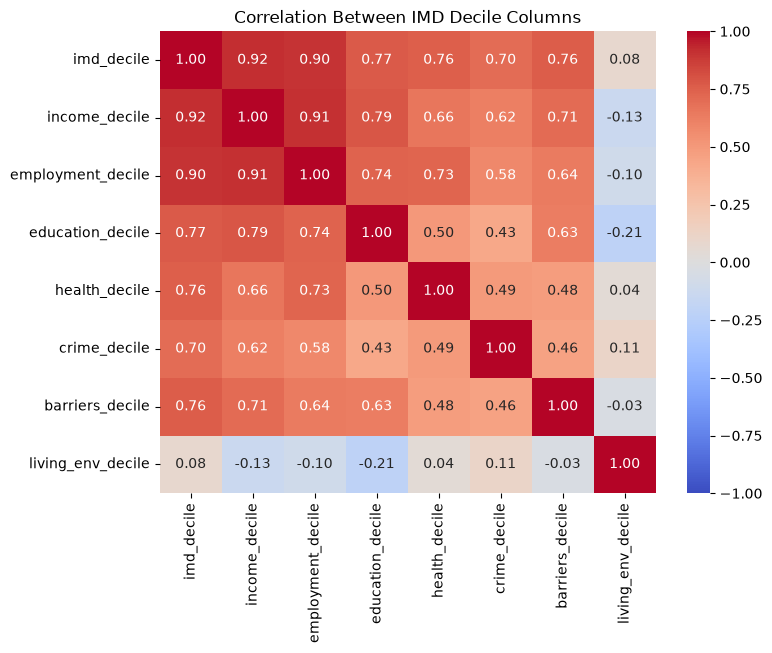

In [16]:
# visualise correlation between IMD decile columns:

import seaborn as sns
import matplotlib.pyplot as plt

decile_cols_all = ["imd_decile"] + list(decile_columns.values())[1:]  
    # main decile & column names from earlier dict

correlation_matrix = gradable[decile_cols_all].corr()

# text output:
print(correlation_matrix.round(2))

# heatmap output:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
    # vmin and vmax prevent seaborn auto-scaling colour range
    # i.e. showing 0.3 has 'hot' red, just if it happens to be the strongest
plt.title("Correlation Between IMD Decile Columns")
plt.show()

-> based on the correlation matrix / heatmap:

Six domains are clustered together, correlating strongly with overall IMD (0.70-0.92) and each other (0.43-0.91): indicating the multicollinearity suspected previously. In simple terms, they are largely 'different flavours' of the same underlying generalised area deprivation (represented in the overall figure).  

With this in mind, including several of these factors in a regression would likely introduce redundant, overlapping input, rather than adding any new information.  

'Living Environment' is the outlier and sits apart from the other deciles, with near-zero or even negative correlation to the other domains; again this may be explained by the urban-rural comparison considered earlier. Despite its independence, this domain is not a useful inclusion, as shown by the very small effect size exposed earlier.    

Based on this, I am going to select two domains for regression modelling:
- 'Income': the strongest standalone predictor (ε²=0.023675), an easily understood domain, and reflective of general deprivation levels.  
- 'Crime': the most modestly correlated domain in the cluster (0.43–0.62), with a small but still significant standalone effect (ε²=0.0117).

My logic here is that income and crime levels are two suitable candidates, yet not so closely linked that they expose the same, general deprivation factors; a high income area could have higher or lower crime rates, and vice-versa.  

As a fallback - if the income-crime domain model isn't sufficiently robust - I'll swap from the domain-pair model to an overall IMD decile model (i.e. using general, combined deprivation rather than specific domain factors).  

In order to verify my thoughts around the Living Environment urban-rural gap:

In [17]:
# living environment distribution vs. overall:
london_lsoas = df.loc[df["lsoa21cd"].notna(),["lsoa21cd", "living_env_decile", "imd_decile"]].drop_duplicates("lsoa21cd")

print(f"Unique London LSOAs represented: {len(london_lsoas)}")
print("\nLiving Environment decile distribution:")
print(london_lsoas["living_env_decile"].value_counts().sort_index())
print("\nOverall IMD decile distribution (for comparison):")
print(london_lsoas["imd_decile"].value_counts().sort_index())

Unique London LSOAs represented: 4713

Living Environment decile distribution:
living_env_decile
1.0      686
2.0     1107
3.0     1029
4.0      770
5.0      500
6.0      300
7.0      179
8.0       88
9.0       42
10.0      12
Name: count, dtype: int64

Overall IMD decile distribution (for comparison):
imd_decile
1.0     193
2.0     667
3.0     807
4.0     682
5.0     546
6.0     447
7.0     410
8.0     356
9.0     330
10.0    275
Name: count, dtype: int64


-> as expected, living environment decile distribution is skewed more stronly towards lower deciles.   

Finally, I will save the domain-enriched data:

In [18]:
df.to_csv("../data/processed/fsa_london_establishments_with_domains.csv", index=False)
print(f"Saved {len(df)} rows, {len(df.columns)} columns.")

Saved 81217 rows, 40 columns.


### Notebook summary & parked enhancements

This notebook joined the existing FSA Food Hygiene Ratings data (with IMD overall deciles already joined) to domain-level 2025 Deprivation deciles, again on LSOA-linked rows only.    

Kruskal-Wallis tests were applied to all 7 domain deciles as well as the overall decile, with effect size being assessed alongside statistical significance confirmation for each.  

Decile correlation was checked, with the suspected multicollinearity identifed for all but 'Living Environment' (with the London-wide domain skew explaining the lack of correlation and effect size for this domain).  

On the basis of the findings in this notebook, I have decided to use Income Decile and Crime Decile in my regression model, chosen based on effect size and their relatively modest correlation. Overall IMD Decile will be used as an alternative fallback if the initial model isn't sufficiently robust.  

Having saved the latest DataFrame to disk, I will proceed to modelling in a separate notebook.